# Phase 2: Feature Engineering & Demand Forecasting

## Objective
Build and evaluate models to predict next-day peak electricity demand for the UK grid.

## Research Questions Addressed
1. Can we accurately predict next-day peak electricity demand using historical patterns and temporal features?
2. What features (time-based, weather, generation mix) are most predictive of demand?
4. How has the UK energy transition (coal phase-out, wind/solar growth) affected demand forecasting difficulty?

## Why This Matters
Energy companies need accurate demand forecasts for grid planning, pricing, and resource allocation. As the UK grid shifts from dispatchable fossil fuels (coal, gas) toward intermittent renewables (wind, solar), forecasting becomes both more important and more challenging. A model that can predict tomorrow's peak demand helps grid operators decide how much backup capacity to keep online.

## Approach
We train five models of increasing complexity:
1. **Persistence baseline** - tomorrow's peak = today's peak (simplest possible, no ML)
2. **Seasonal naive baseline** - tomorrow's peak = same weekday last week (captures weekly pattern)
3. **Prophet** - Meta's time-series decomposition model (trend + seasonality + holidays)
4. **Random Forest** - bagging ensemble over tabular features
5. **XGBoost** - boosting ensemble over tabular features

The baselines establish a minimum bar. If ML models can't beat "just use last week's value", the added complexity isn't justified. Comparing Random Forest (bagging) vs XGBoost (boosting) shows understanding of different ensemble strategies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

DATA_RAW = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')

C:\Users\sandy\OneDrive - Robert Gordon University\Projects\uk-energy-intelligence\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading

We load three datasets from Phase 1:
- **Historic demand** - our target variable (peak daily ND)
- **Generation mix** - wind/solar shares that drive variability
- **Weather** - temperature is the strongest external demand driver

We also load a UK public holidays dataset to flag unusual demand days.

In [2]:
# Load datasets
demand = pd.read_csv(DATA_RAW / 'historic_demand.csv')
gen = pd.read_csv(DATA_RAW / 'generation_mix.csv')
weather = pd.read_csv(DATA_RAW / 'weather_london.csv')

# Parse dates
demand['SETTLEMENT_DATE'] = pd.to_datetime(demand['SETTLEMENT_DATE'], format='mixed', dayfirst=True)
demand['DATETIME'] = demand['SETTLEMENT_DATE'] + pd.to_timedelta((demand['SETTLEMENT_PERIOD'] - 1) * 30, unit='min')
gen['DATETIME'] = pd.to_datetime(gen['DATETIME'])
weather['datetime'] = pd.to_datetime(weather['datetime'])

print(f'Demand: {demand.shape[0]:,} records, {demand["DATETIME"].min()} to {demand["DATETIME"].max()}')
print(f'Generation: {gen.shape[0]:,} records, {gen["DATETIME"].min()} to {gen["DATETIME"].max()}')
print(f'Weather: {weather.shape[0]:,} records, {weather["datetime"].min()} to {weather["datetime"].max()}')

Demand: 105,216 records, 2020-01-01 00:00:00 to 2025-12-31 23:30:00
Generation: 301,956 records, 2009-01-01 00:00:00 to 2026-03-23 17:30:00
Weather: 54,600 records, 2020-01-01 00:00:00 to 2026-03-24 23:00:00


## 2. Data Summary & Quality Assessment

Before any cleaning, we inspect each dataset to understand its structure, identify issues, and justify our preprocessing decisions. This follows good data science practice - decisions should be driven by evidence in the data, not assumptions.

In [3]:
# --- Demand data summary ---
print('=== DEMAND DATA ===')
print(f'Shape: {demand.shape}')
print(f'\nMissing values (columns with any):')
missing = demand.isnull().sum()
print(missing[missing > 0])
print(f'\nKey column stats:')
print(demand[['ND', 'TSD', 'EMBEDDED_WIND_GENERATION', 'EMBEDDED_SOLAR_GENERATION']].describe().round(0))

# Check for duplicate timestamps
dup_times = demand['DATETIME'].duplicated().sum()
print(f'\nDuplicate timestamps: {dup_times}')

# Check for gaps in the time series
demand_sorted = demand.sort_values('DATETIME')
time_diffs = demand_sorted['DATETIME'].diff().dropna()
expected_interval = pd.Timedelta(minutes=30)
gaps = time_diffs[time_diffs > expected_interval]
print(f'Time gaps (> 30 min): {len(gaps)}')
if len(gaps) > 0:
    print(gaps.value_counts().head())

=== DEMAND DATA ===
Shape: (105216, 25)

Missing values (columns with any):
SCOTTISH_TRANSFER    52608
dtype: int64

Key column stats:
             ND       TSD  EMBEDDED_WIND_GENERATION  EMBEDDED_SOLAR_GENERATION
count  105216.0  105216.0                  105216.0                   105216.0
mean    26770.0   28738.0                    1887.0                     1579.0
std      6218.0    5933.0                    1213.0                     2484.0
min     12803.0   15297.0                     125.0                        0.0
25%     21898.0   24228.0                     912.0                        0.0
50%     25884.0   27808.0                    1557.0                        5.0
75%     30709.0   32383.0                    2625.0                     2526.0
max     46433.0   47760.0                    5962.0                    14044.0

Duplicate timestamps: 12
Time gaps (> 30 min): 6
DATETIME
0 days 01:30:00    6
Name: count, dtype: int64


In [4]:
# --- Generation mix data summary ---
print('=== GENERATION MIX DATA ===')
print(f'Shape: {gen.shape}')
print(f'\nMissing values (columns with any):')
missing_gen = gen.isnull().sum()
print(missing_gen[missing_gen > 0] if missing_gen.sum() > 0 else 'None')
print(f'\nKey column stats:')
fuel_cols = ['GAS', 'COAL', 'NUCLEAR', 'WIND', 'SOLAR', 'HYDRO', 'BIOMASS', 'IMPORTS']
print(gen[fuel_cols + ['CARBON_INTENSITY', 'GENERATION']].describe().round(0))

=== GENERATION MIX DATA ===
Shape: (301956, 35)

Missing values (columns with any):
None

Key column stats:
            GAS      COAL   NUCLEAR      WIND     SOLAR     HYDRO   BIOMASS  \
count  301956.0  301956.0  301956.0  301956.0  301956.0  301956.0  301956.0   
mean    12012.0    5478.0    6262.0    4081.0     942.0     395.0     957.0   
std      5522.0    6517.0    1541.0    3857.0    1907.0     245.0    1107.0   
min       738.0       0.0    2065.0       0.0       0.0       0.0       0.0   
25%      7450.0       0.0    4990.0    1005.0       0.0     191.0       0.0   
50%     12039.0    1790.0    6426.0    2808.0       0.0     364.0       0.0   
75%     16327.0   10488.0    7557.0    5965.0     891.0     562.0    1993.0   
max     27868.0   26044.0    9342.0   18439.0   14046.0    1403.0    3415.0   

        IMPORTS  CARBON_INTENSITY  GENERATION  
count  301956.0          301956.0    301956.0  
mean     2561.0             290.0     34507.0  
std      1705.0             149.0   

In [5]:
# --- Weather data summary ---
print('=== WEATHER DATA ===')
print(f'Shape: {weather.shape}')
print(f'\nMissing values:')
print(weather.isnull().sum())
print(f'\nStats:')
print(weather[['temperature_2m', 'wind_speed_10m', 'cloud_cover', 'precipitation']].describe().round(1))

# Note on weather data limitation
print(f'\nNote: Weather data is for London (51.51, -0.13) only.')
print(f'London and the South East account for roughly a third of UK electricity consumption,')
print(f'making London temperature a reasonable proxy for national demand patterns.')
print(f'Limitation: Ideally we would use a population-weighted average across multiple UK cities.')

=== WEATHER DATA ===
Shape: (54600, 5)

Missing values:
datetime          0
temperature_2m    0
wind_speed_10m    0
cloud_cover       0
precipitation     0
dtype: int64

Stats:
       temperature_2m  wind_speed_10m  cloud_cover  precipitation
count         54600.0         54600.0      54600.0        54600.0
mean             11.5            14.2         67.0            0.1
std               6.2             7.5         39.2            0.4
min             -10.3             0.0          0.0            0.0
25%               7.2             8.5         28.0            0.0
50%              11.2            12.7         92.0            0.0
75%              15.8            18.5        100.0            0.0
max              37.9            68.0        100.0           14.7

Note: Weather data is for London (51.51, -0.13) only.
London and the South East account for roughly a third of UK electricity consumption,
making London temperature a reasonable proxy for national demand patterns.
Limitation: Id

## 3. Data Cleaning & Preprocessing

Based on the data summary above, we apply the following cleaning steps:

1. **Resample demand to daily aggregates** - we're forecasting daily peak demand, so we aggregate half-hourly data to daily max/min. We intentionally **exclude TSD (Transmission System Demand) and mean_demand** from our feature set because TSD is essentially another measure of the same quantity as ND - they correlate near-perfectly. Including them would cause the model to "cheat" by using a near-duplicate of the target, inflating accuracy without genuine predictive value.
2. **Drop SCOTTISH_TRANSFER** - ~50% missing values, likely introduced partway through the dataset. Not reliable for modelling.
3. **Align generation mix with demand** - generation data is hourly, demand is half-hourly. We resample both to daily.
4. **Merge weather data** - resample hourly weather to daily aggregates (mean temp, max wind, mean cloud cover, total precipitation).
5. **Handle COVID period** - early 2020 demand patterns are atypical (lockdowns caused unprecedented demand drops). We flag rather than remove these, so the model can learn the pattern but we can evaluate with/without.
6. **Handle remaining nulls** - after merging, drop any rows with missing values created by date misalignment.

**Note on dataset size:** The final dataset contains ~2,162 daily observations. This is a genuine constraint of the problem - we only have 6 years of daily demand data (2020-2025). This is why we use relatively simple model configurations (200 trees, not 2000) with regularisation to avoid overfitting. The baseline comparisons are especially important with smaller datasets to confirm ML models add genuine value.

In [6]:
# Step 1: Resample demand to daily aggregates
# We extract the key daily statistics that a forecasting model would use
# NOTE: We exclude TSD and mean_demand to avoid target leakage (see explanation above)
# We keep min_demand for now but will convert it to a lag feature in the feature engineering
# step - same-day min_demand wouldn't be available at forecast time
daily_demand = demand.set_index('DATETIME').resample('D').agg({
    'ND': ['max', 'min'],
    'EMBEDDED_WIND_GENERATION': 'mean',
    'EMBEDDED_SOLAR_GENERATION': 'mean',
}).reset_index()

# Flatten multi-level columns
daily_demand.columns = [
    'date', 'peak_demand', 'min_demand',
    'embedded_wind_avg', 'embedded_solar_avg'
]
daily_demand['date'] = daily_demand['date'].dt.date
daily_demand['date'] = pd.to_datetime(daily_demand['date'])

print(f'Daily demand: {len(daily_demand)} days')
print(f'Columns: {list(daily_demand.columns)}')
print(daily_demand.head())

Daily demand: 2192 days
Columns: ['date', 'peak_demand', 'min_demand', 'embedded_wind_avg', 'embedded_solar_avg']
        date  peak_demand  min_demand  embedded_wind_avg  embedded_solar_avg
0 2020-01-01        37271       22322        1553.541667          199.041667
1 2020-01-02        40528       20398        3782.104167          136.187500
2 2020-01-03        41630       22201        2681.875000          534.562500
3 2020-01-04        38644       21130        2473.687500          389.666667
4 2020-01-05        39634       21034        2623.458333          173.895833


In [7]:
# Step 2: Resample generation mix to daily
# Filter to overlap with demand data range (2020 onward)
gen_filtered = gen[gen['DATETIME'] >= '2020-01-01'].copy()

daily_gen = gen_filtered.set_index('DATETIME').resample('D').agg({
    'WIND': 'mean',
    'SOLAR': 'mean',
    'GAS': 'mean',
    'NUCLEAR': 'mean',
    'IMPORTS': 'mean',
    'GENERATION': 'mean',
    'CARBON_INTENSITY': 'mean',
    'RENEWABLE_perc': 'mean',
    'FOSSIL_perc': 'mean',
}).reset_index()

daily_gen.columns = [
    'date', 'grid_wind_avg', 'grid_solar_avg', 'grid_gas_avg',
    'grid_nuclear_avg', 'grid_imports_avg', 'total_generation_avg',
    'carbon_intensity_avg', 'renewable_pct_avg', 'fossil_pct_avg'
]
daily_gen['date'] = daily_gen['date'].dt.date
daily_gen['date'] = pd.to_datetime(daily_gen['date'])

print(f'Daily generation: {len(daily_gen)} days')
print(daily_gen.head())

Daily generation: 2274 days
        date  grid_wind_avg  grid_solar_avg  grid_gas_avg  grid_nuclear_avg  \
0 2020-01-01    5804.687500      199.979167   9141.770833       6958.770833   
1 2020-01-02   11256.000000      136.833333   7715.500000       6942.000000   
2 2020-01-03   11223.333333      535.666667   7326.625000       6922.812500   
3 2020-01-04    8923.354167      391.000000   7786.791667       6796.437500   
4 2020-01-05    9541.479167      174.604167   6590.729167       6764.312500   

   grid_imports_avg  total_generation_avg  carbon_intensity_avg  \
0       3361.541667          31133.750000            173.520833   
1       1063.770833          34611.791667            153.791667   
2       2707.916667          35785.208333            147.729167   
3       2702.208333          33305.333333            159.500000   
4       2659.333333          32538.395833            150.562500   

   renewable_pct_avg  fossil_pct_avg  
0          25.972917       32.412500  
1          42.12

In [8]:
# Step 3: Resample weather to daily
daily_weather = weather.set_index('datetime').resample('D').agg({
    'temperature_2m': ['mean', 'max', 'min'],
    'wind_speed_10m': ['mean', 'max'],
    'cloud_cover': 'mean',
    'precipitation': 'sum',
}).reset_index()

daily_weather.columns = [
    'date', 'temp_mean', 'temp_max', 'temp_min',
    'wind_speed_mean', 'wind_speed_max',
    'cloud_cover_mean', 'precipitation_total'
]
daily_weather['date'] = daily_weather['date'].dt.date
daily_weather['date'] = pd.to_datetime(daily_weather['date'])

print(f'Daily weather: {len(daily_weather)} days')
print(daily_weather.head())

Daily weather: 2275 days
        date  temp_mean  temp_max  temp_min  wind_speed_mean  wind_speed_max  \
0 2020-01-01   5.029167       6.6       2.0         5.512500             9.1   
1 2020-01-02   8.320833      10.1       5.7        18.995833            26.6   
2 2020-01-03   7.579167      10.8       3.3        18.333333            27.6   
3 2020-01-04   4.375000       8.1       2.0        12.825000            20.2   
4 2020-01-05   5.925000       8.6       4.0        11.629167            17.4   

   cloud_cover_mean  precipitation_total  
0         89.708333                  0.0  
1         90.375000                  0.0  
2         55.958333                  3.1  
3         39.083333                  0.0  
4         66.166667                  0.0  


In [9]:
# Step 4: Merge all datasets on date
df = daily_demand.merge(daily_gen, on='date', how='inner')
df = df.merge(daily_weather, on='date', how='inner')

# Step 5: Flag COVID lockdown periods (atypical demand patterns)
# UK lockdowns: March 2020 - July 2021 (various phases)
df['is_covid_period'] = ((df['date'] >= '2020-03-23') & (df['date'] <= '2021-07-19')).astype(int)

# Step 6: Check for and handle remaining nulls
null_counts = df.isnull().sum()
print(f'Merged dataset: {len(df)} days, {df.shape[1]} columns')
print(f'\nNull values after merge:')
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else 'None - clean!')

# Drop any rows with nulls (from date misalignment)
df = df.dropna().reset_index(drop=True)
print(f'\nFinal clean dataset: {len(df)} days')
print(f'Date range: {df["date"].min()} to {df["date"].max()}')

Merged dataset: 2192 days, 22 columns

Null values after merge:
None - clean!

Final clean dataset: 2192 days
Date range: 2020-01-01 00:00:00 to 2025-12-31 00:00:00


## 4. Feature Engineering

Good features are the difference between a mediocre model and a strong one. We engineer features in four categories:

1. **Temporal features** - capture the strong seasonal, weekly, and yearly patterns found in Phase 1 EDA.
2. **Lag features** - yesterday's demand, last week's demand, etc. These capture autocorrelation in the time series.
3. **Rolling statistics** - smoothed trends that capture recent demand behaviour.
4. **Holiday flags** - Phase 1 anomaly detection showed public holidays cause significant demand drops.

Weather and generation mix features are already in the merged dataset from the preprocessing step.

In [10]:
# --- Temporal features ---
# These capture the seasonal patterns identified in Phase 1 EDA
df['day_of_week'] = df['date'].dt.dayofweek          # 0=Mon, 6=Sun
df['day_of_year'] = df['date'].dt.dayofyear           # 1-365
df['month'] = df['date'].dt.month                     # 1-12
df['quarter'] = df['date'].dt.quarter                 # 1-4
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

# Cyclical encoding for month and day_of_week
# Sine/cosine encoding so December (12) is close to January (1)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

print(f'Temporal features added: day_of_week, day_of_year, month, quarter, is_weekend, week_of_year, cyclical encodings')

Temporal features added: day_of_week, day_of_year, month, quarter, is_weekend, week_of_year, cyclical encodings


In [11]:
# --- Lag features ---
# These capture autocorrelation - demand today is strongly related to demand yesterday/last week
# Critical: we only use PAST values to avoid data leakage
lag_periods = [1, 2, 3, 7, 14, 28]  # days ago

for lag in lag_periods:
    df[f'peak_demand_lag_{lag}'] = df['peak_demand'].shift(lag)

# Convert min_demand to a lag feature - same-day min_demand wouldn't be
# available at forecast time, but yesterday's min gives useful information
# about the demand range (peak-to-trough ratio indicates load variability)
df['min_demand_lag_1'] = df['min_demand'].shift(1)
df = df.drop(columns=['min_demand'])

# Temperature lags (yesterday's temp, last week's temp)
df['temp_mean_lag_1'] = df['temp_mean'].shift(1)
df['temp_mean_lag_7'] = df['temp_mean'].shift(7)

print(f'Lag features added for periods: {lag_periods}')
print(f'Also added: min_demand_lag_1, temp lags (1 day, 7 days)')
print(f'Dropped raw min_demand (same-day leakage)')

Lag features added for periods: [1, 2, 3, 7, 14, 28]
Also added: min_demand_lag_1, temp lags (1 day, 7 days)
Dropped raw min_demand (same-day leakage)


In [12]:
# --- Rolling statistics ---
# Smoothed trends capture whether demand has been rising or falling recently
rolling_windows = [7, 14, 30]

for window in rolling_windows:
    # Use shift(1) to avoid including today's value (would be data leakage)
    df[f'peak_demand_rolling_mean_{window}'] = df['peak_demand'].shift(1).rolling(window).mean()
    df[f'peak_demand_rolling_std_{window}'] = df['peak_demand'].shift(1).rolling(window).std()
    df[f'temp_rolling_mean_{window}'] = df['temp_mean'].shift(1).rolling(window).mean()

print(f'Rolling features added for windows: {rolling_windows}')

Rolling features added for windows: [7, 14, 30]


In [13]:
# --- Holiday flags ---
# Phase 1 showed public holidays cause significant demand drops
# We use a simple list of UK bank holidays rather than an external library
# to keep dependencies minimal
uk_holidays = [
    # 2020
    '2020-01-01', '2020-04-10', '2020-04-13', '2020-05-08', '2020-05-25',
    '2020-08-31', '2020-12-25', '2020-12-28',
    # 2021
    '2021-01-01', '2021-04-02', '2021-04-05', '2021-05-03', '2021-05-31',
    '2021-08-30', '2021-12-27', '2021-12-28',
    # 2022
    '2022-01-03', '2022-04-15', '2022-04-18', '2022-05-02', '2022-06-02',
    '2022-06-03', '2022-08-29', '2022-09-19', '2022-12-26', '2022-12-27',
    # 2023
    '2023-01-02', '2023-04-07', '2023-04-10', '2023-05-01', '2023-05-08',
    '2023-05-29', '2023-08-28', '2023-12-25', '2023-12-26',
    # 2024
    '2024-01-01', '2024-03-29', '2024-04-01', '2024-05-06', '2024-05-27',
    '2024-08-26', '2024-12-25', '2024-12-26',
    # 2025
    '2025-01-01', '2025-04-18', '2025-04-21', '2025-05-05', '2025-05-26',
    '2025-08-25', '2025-12-25', '2025-12-26',
]
uk_holidays = pd.to_datetime(uk_holidays)
df['is_holiday'] = df['date'].isin(uk_holidays).astype(int)

print(f'Holiday flags added: {df["is_holiday"].sum()} holiday days in dataset')

Holiday flags added: 51 holiday days in dataset


In [14]:
# --- Drop rows with NaN from lag/rolling features ---
# The first 30 days will have NaN due to rolling(30), which is expected
rows_before = len(df)
df = df.dropna().reset_index(drop=True)
rows_after = len(df)

print(f'Dropped {rows_before - rows_after} rows due to lag/rolling NaN values')
print(f'Final dataset: {rows_after} days, {df.shape[1]} features')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'\nTarget variable (peak_demand) stats:')
print(df['peak_demand'].describe().round(0))

Dropped 30 rows due to lag/rolling NaN values
Final dataset: 2162 days, 50 features
Date range: 2020-01-31 to 2025-12-31

Target variable (peak_demand) stats:
count     2162.0
mean     33404.0
std       5734.0
min      21680.0
25%      28560.0
50%      32663.0
75%      38120.0
max      46433.0
Name: peak_demand, dtype: float64


In [15]:
# Save processed dataset
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
df.to_csv(DATA_PROCESSED / 'daily_features.csv', index=False)
print(f'Saved processed features to {DATA_PROCESSED / "daily_features.csv"}')

Saved processed features to ..\data\processed\daily_features.csv


## 5. Train/Test Split

**Critical: we split by time, not randomly.** Random splitting would allow the model to "see" future data during training, which is data leakage. In a real forecasting scenario, you only have past data available when making predictions.

This is the same principle demonstrated in the financial feature selection project (CMM507), where random splitting inflated performance by up to 16% compared to chronological splitting.

We use the last 6 months as the test set, and everything before as training data.

In [16]:
# Time-based split: last 6 months for testing
split_date = df['date'].max() - pd.Timedelta(days=180)

train = df[df['date'] <= split_date].copy()
test = df[df['date'] > split_date].copy()

# Define feature columns (exclude target, date, and identifiers)
# We also exclude peak_demand_lag_1 and peak_demand_lag_7 from the feature set
# because the baseline models use them directly - we keep them in the dataframe
# for baseline evaluation but don't feed them as separate named features to avoid confusion
exclude_cols = ['date', 'peak_demand']
feature_cols = [c for c in df.columns if c not in exclude_cols]

X_train = train[feature_cols]
y_train = train['peak_demand']
X_test = test[feature_cols]
y_test = test['peak_demand']

print(f'Split date: {split_date.date()}')
print(f'Training: {len(train)} days ({train["date"].min().date()} to {train["date"].max().date()})')
print(f'Testing:  {len(test)} days ({test["date"].min().date()} to {test["date"].max().date()})')
print(f'Features: {len(feature_cols)}')
print(f'\nFeature list:')
for f in sorted(feature_cols):
    print(f'  {f}')

Split date: 2025-07-04
Training: 1982 days (2020-01-31 to 2025-07-04)
Testing:  180 days (2025-07-05 to 2025-12-31)
Features: 48

Feature list:
  carbon_intensity_avg
  cloud_cover_mean
  day_of_week
  day_of_year
  dow_cos
  dow_sin
  embedded_solar_avg
  embedded_wind_avg
  fossil_pct_avg
  grid_gas_avg
  grid_imports_avg
  grid_nuclear_avg
  grid_solar_avg
  grid_wind_avg
  is_covid_period
  is_holiday
  is_weekend
  min_demand_lag_1
  month
  month_cos
  month_sin
  peak_demand_lag_1
  peak_demand_lag_14
  peak_demand_lag_2
  peak_demand_lag_28
  peak_demand_lag_3
  peak_demand_lag_7
  peak_demand_rolling_mean_14
  peak_demand_rolling_mean_30
  peak_demand_rolling_mean_7
  peak_demand_rolling_std_14
  peak_demand_rolling_std_30
  peak_demand_rolling_std_7
  precipitation_total
  quarter
  renewable_pct_avg
  temp_max
  temp_mean
  temp_mean_lag_1
  temp_mean_lag_7
  temp_min
  temp_rolling_mean_14
  temp_rolling_mean_30
  temp_rolling_mean_7
  total_generation_avg
  week_of_year
  

## 6. Model Training & Evaluation

We define a consistent evaluation framework, then train each model and compare results.

**Metrics used:**
- **MAE (Mean Absolute Error)** - average prediction error in MW, easy to interpret for stakeholders
- **RMSE (Root Mean Squared Error)** - penalises large errors more heavily than MAE
- **MAPE (Mean Absolute Percentage Error)** - relative error, allows comparison across different scales
- **R-squared** - proportion of variance in actual demand explained by the model. Included for completeness, but note that for time-series data R-squared can be inflated by seasonal trends - a model that simply captures "winter is higher than summer" will score well even with poor day-to-day accuracy. MAE/MAPE are more reliable indicators of practical forecasting quality.

In [17]:
# Evaluation helper
from sklearn.metrics import r2_score

def evaluate_model(y_true, y_pred, model_name):
    """Calculate and return metrics for a model's predictions."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)
    
    print(f'{model_name}:')
    print(f'  MAE:  {mae:,.0f} MW')
    print(f'  RMSE: {rmse:,.0f} MW')
    print(f'  MAPE: {mape:.2f}%')
    print(f'  R2:   {r2:.4f}')
    
    return {'model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

results = []

### 6.1 Persistence Baseline

The simplest possible forecast: tomorrow's peak demand equals today's peak demand. This is the absolute minimum bar any model must beat. If an ML model can't outperform this, it's not adding value.

In [18]:
# Persistence: predict today's peak as tomorrow's peak
y_pred_persistence = test['peak_demand_lag_1'].values
results.append(evaluate_model(y_test, y_pred_persistence, 'Persistence Baseline'))

Persistence Baseline:
  MAE:  1,468 MW
  RMSE: 1,867 MW
  MAPE: 4.58%
  R2:   0.8711


### 6.2 Seasonal Naive Baseline

A slightly smarter baseline: tomorrow's peak demand equals the peak demand from the same weekday last week. This captures the strong weekly pattern found in Phase 1 EDA (weekdays ~27,700 MW vs weekends ~24,500 MW).

In [19]:
# Seasonal naive: predict same weekday last week's peak
y_pred_seasonal = test['peak_demand_lag_7'].values
results.append(evaluate_model(y_test, y_pred_seasonal, 'Seasonal Naive Baseline'))

Seasonal Naive Baseline:
  MAE:  1,631 MW
  RMSE: 2,168 MW
  MAPE: 4.97%
  R2:   0.8263


### 6.3 Prophet

**What is Prophet?** A time-series forecasting model developed by Meta (2017). It decomposes a time series into three additive components:
- **Trend** - long-term direction (e.g., demand declining due to efficiency gains)
- **Seasonality** - repeating patterns (yearly, weekly)
- **Holidays** - irregular events that cause demand drops

The model fits: `y(t) = trend(t) + seasonality(t) + holidays(t) + error(t)`

**Why use it here?** Demand data has exactly the patterns Prophet handles well - yearly seasonality (winter/summer), weekly seasonality (weekday/weekend), and holiday effects. It also handles missing data gracefully and doesn't require stationary data.

**Trade-off vs XGBoost:** Prophet is more interpretable for seasonal decomposition but less flexible with external features. It works directly on the time series without needing hand-crafted lag/rolling features.

In [20]:
# Prophet requires specific column names: 'ds' (date) and 'y' (target)
prophet_train = train[['date', 'peak_demand']].rename(columns={'date': 'ds', 'peak_demand': 'y'})
prophet_test = test[['date', 'peak_demand']].rename(columns={'date': 'ds', 'peak_demand': 'y'})

# Add UK holidays as a regressor
prophet_holidays = pd.DataFrame({
    'holiday': 'uk_bank_holiday',
    'ds': uk_holidays,
})

# Fit Prophet
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,  # we're working with daily data
    holidays=prophet_holidays,
    changepoint_prior_scale=0.05,  # regularisation to prevent overfitting
)
model_prophet.fit(prophet_train)

# Predict on test dates
prophet_forecast = model_prophet.predict(prophet_test[['ds']])
y_pred_prophet = prophet_forecast['yhat'].values

results.append(evaluate_model(y_test, y_pred_prophet, 'Prophet'))

17:01:59 - cmdstanpy - INFO - Chain [1] start processing
17:01:59 - cmdstanpy - INFO - Chain [1] done processing


Prophet:
  MAE:  1,120 MW
  RMSE: 1,463 MW
  MAPE: 3.44%
  R2:   0.9209


### 6.4 Random Forest

**What is Random Forest?** An ensemble method that trains many decision trees on random subsets of the data (bagging) and averages their predictions. Each tree sees a different random sample of rows and features, which reduces overfitting.

**Why use it here?** It's a strong baseline for tabular regression. By comparing it against XGBoost, we can assess whether boosting (sequential error correction) outperforms bagging (parallel averaging) on this specific problem. RF also provides feature importance rankings.

In [21]:
# Random Forest
model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

results.append(evaluate_model(y_test, y_pred_rf, 'Random Forest'))

Random Forest:
  MAE:  942 MW
  RMSE: 1,229 MW
  MAPE: 2.94%
  R2:   0.9442


### 6.5 XGBoost

**What is XGBoost?** An ensemble method that trains decision trees sequentially (boosting). Each new tree focuses on correcting the errors made by previous trees, gradually improving predictions.

**Key difference from Random Forest:** RF trains trees independently in parallel (bagging), while XGBoost trains them sequentially where each tree learns from the mistakes of the last (boosting). Boosting typically achieves higher accuracy but is more prone to overfitting, which is why we use regularisation parameters.

**Why use it here?** XGBoost is the standard choice for structured/tabular prediction tasks. It handles nonlinear relationships between features well and provides built-in feature importance.

In [22]:
# XGBoost
model_xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

results.append(evaluate_model(y_test, y_pred_xgb, 'XGBoost'))

XGBoost:
  MAE:  785 MW
  RMSE: 1,026 MW
  MAPE: 2.46%
  R2:   0.9611


## 7. Model Comparison

=== Model Comparison ===
                            MAE    RMSE  MAPE      R2
model                                                
Persistence Baseline     1468.0  1867.0  4.58  0.8711
Seasonal Naive Baseline  1631.0  2168.0  4.97  0.8263
Prophet                  1120.0  1463.0  3.44  0.9209
Random Forest             942.0  1229.0  2.94  0.9442
XGBoost                   785.0  1026.0  2.46  0.9611


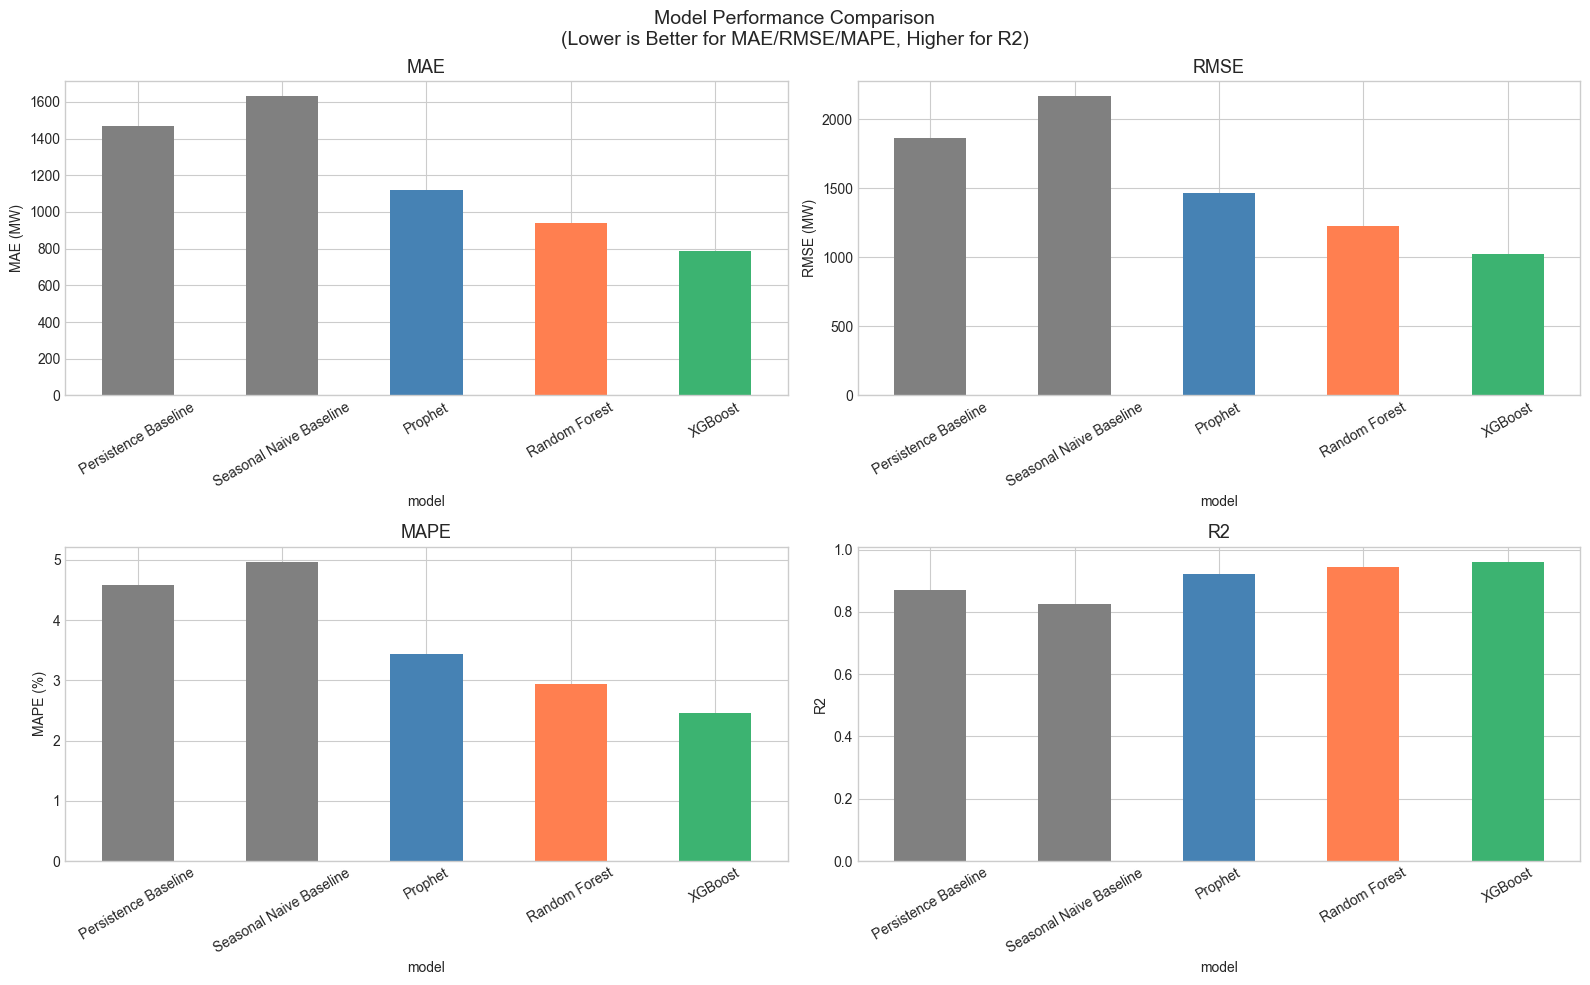

In [23]:
# Compare all models
results_df = pd.DataFrame(results).set_index('model')
results_df['MAE'] = results_df['MAE'].round(0)
results_df['RMSE'] = results_df['RMSE'].round(0)
results_df['MAPE'] = results_df['MAPE'].round(2)
results_df['R2'] = results_df['R2'].round(4)

print('=== Model Comparison ===')
print(results_df.to_string())

# Bar chart comparison - 2x2 grid for readability
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

colors = ['grey', 'grey', 'steelblue', 'coral', 'mediumseagreen']

for i, metric in enumerate(['MAE', 'RMSE', 'MAPE', 'R2']):
    results_df[metric].plot(kind='bar', ax=axes[i], color=colors)
    unit = 'MW' if metric in ['MAE', 'RMSE'] else ('%' if metric == 'MAPE' else '')
    axes[i].set_title(metric, fontsize=13)
    axes[i].set_ylabel(f'{metric} ({unit})' if unit else metric)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Model Performance Comparison\n(Lower is Better for MAE/RMSE/MAPE, Higher for R2)', fontsize=14)
plt.tight_layout()
plt.show()

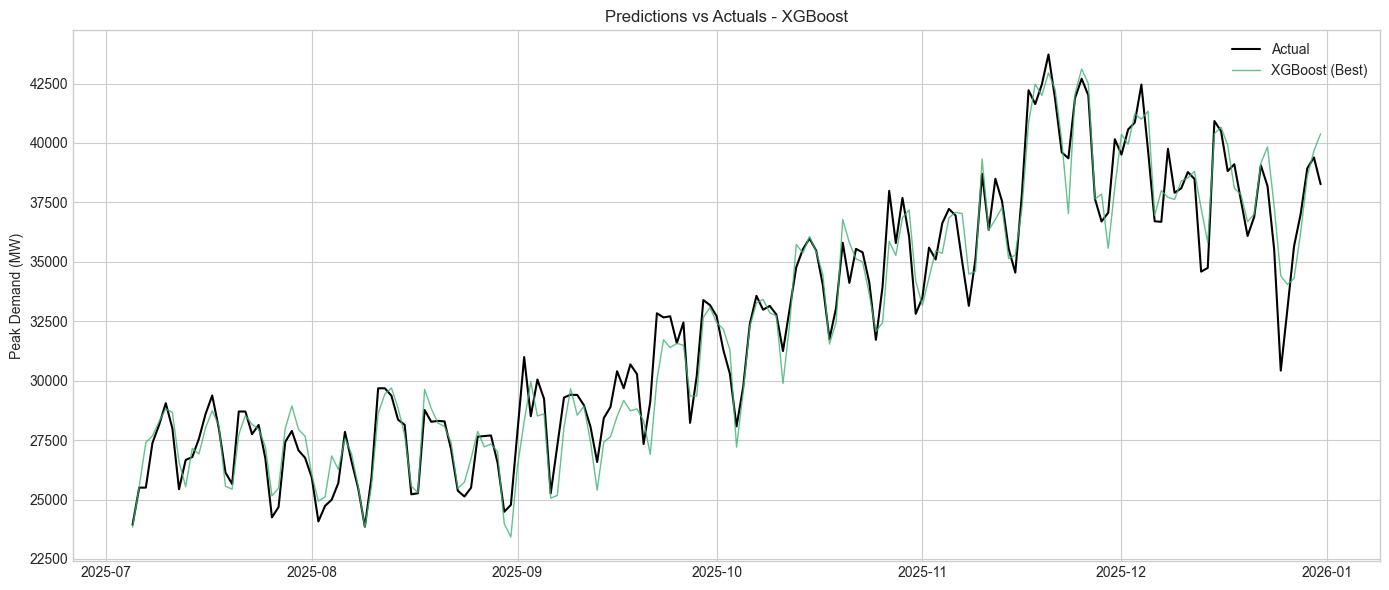

In [24]:
# Predictions vs Actuals plot for best model
best_model = results_df['MAE'].idxmin()
best_preds = {
    'Persistence Baseline': y_pred_persistence,
    'Seasonal Naive Baseline': y_pred_seasonal,
    'Prophet': y_pred_prophet,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
}

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test['date'], y_test, label='Actual', linewidth=1.5, color='black')
ax.plot(test['date'], best_preds[best_model], label=f'{best_model} (Best)', linewidth=1, alpha=0.8, color='mediumseagreen')
ax.set_ylabel('Peak Demand (MW)')
ax.set_title(f'Predictions vs Actuals - {best_model}')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Feature Importance

Understanding which features drive predictions is as important as the predictions themselves. This answers Research Question 2: *What features are most predictive of demand?*

We examine feature importance from both the Random Forest and XGBoost models. If both agree on the top features, we can be more confident in those findings.

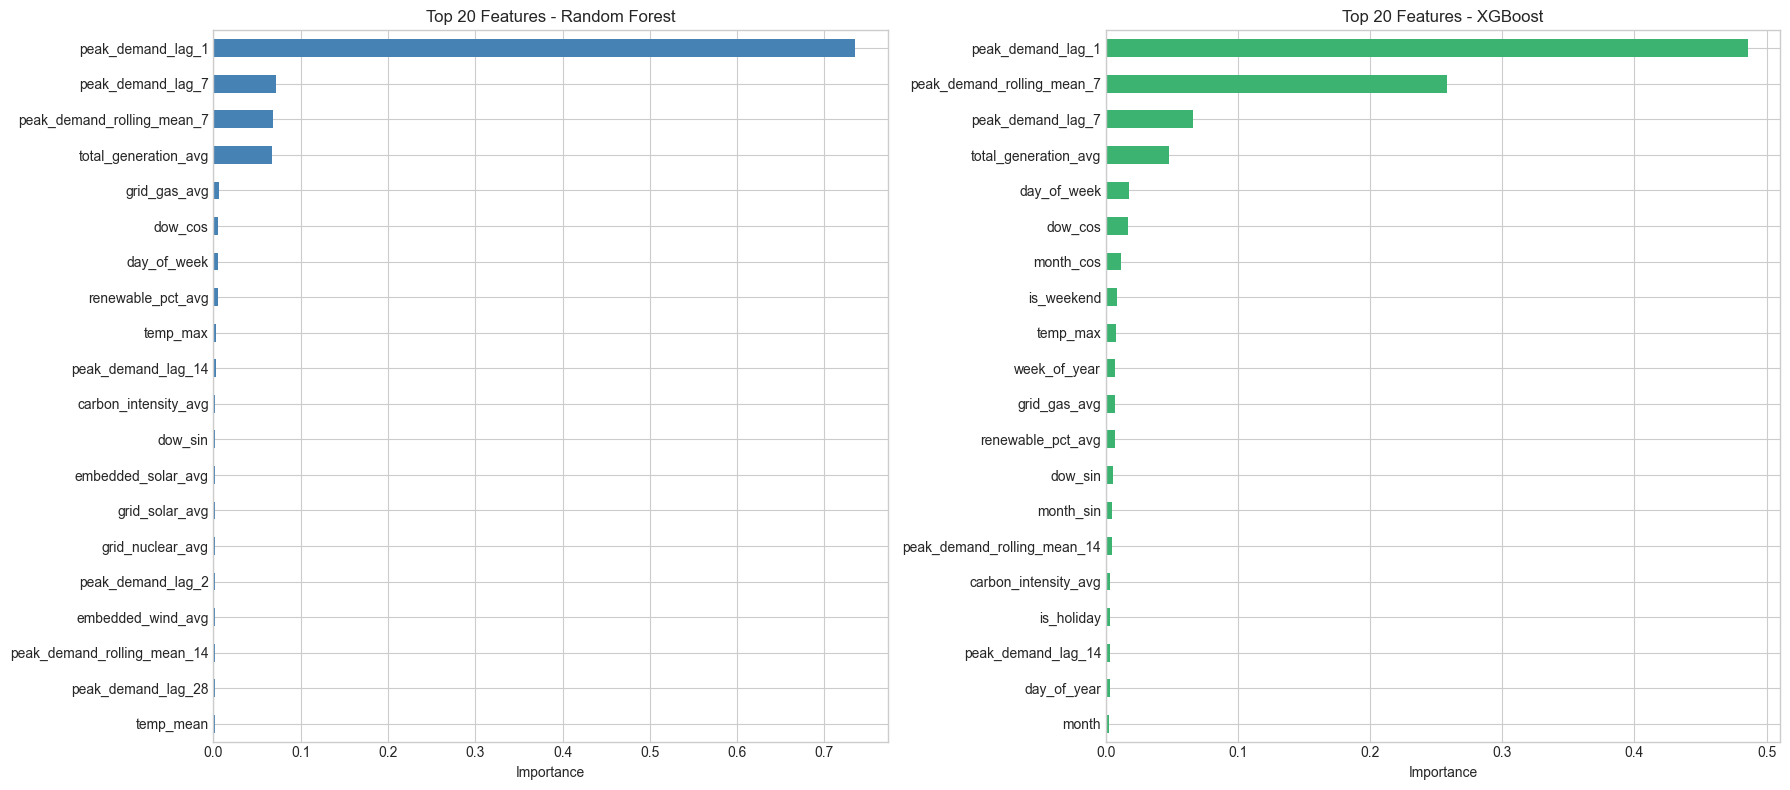

=== Top 10 Features ===
Random Forest                       XGBoost                            
----------------------------------------------------------------------
peak_demand_lag_1              0.7354    peak_demand_lag_1              0.4859
peak_demand_lag_7              0.0714    peak_demand_rolling_mean_7     0.2577
peak_demand_rolling_mean_7     0.0678    peak_demand_lag_7              0.0658
total_generation_avg           0.0665    total_generation_avg           0.0478
grid_gas_avg                   0.0060    day_of_week                    0.0177
dow_cos                        0.0051    dow_cos                        0.0168
day_of_week                    0.0047    month_cos                      0.0115
renewable_pct_avg              0.0047    is_weekend                     0.0085
temp_max                       0.0029    temp_max                       0.0075
peak_demand_lag_14             0.0027    week_of_year                   0.0068


In [25]:
# Feature importance from both tree-based models
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for idx, (model, name) in enumerate([(model_rf, 'Random Forest'), (model_xgb, 'XGBoost')]):
    importances = pd.Series(model.feature_importances_, index=feature_cols)
    top_20 = importances.nlargest(20)
    top_20.plot(kind='barh', ax=axes[idx], color='steelblue' if idx == 0 else 'mediumseagreen')
    axes[idx].set_title(f'Top 20 Features - {name}')
    axes[idx].set_xlabel('Importance')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

# Summary table of top 10 features from each model
rf_top = pd.Series(model_rf.feature_importances_, index=feature_cols).nlargest(10)
xgb_top = pd.Series(model_xgb.feature_importances_, index=feature_cols).nlargest(10)

print('=== Top 10 Features ===')
print(f'{"Random Forest":<35} {"XGBoost":<35}')
print('-' * 70)
for (rf_feat, rf_imp), (xgb_feat, xgb_imp) in zip(rf_top.items(), xgb_top.items()):
    print(f'{rf_feat:<30} {rf_imp:.4f}    {xgb_feat:<30} {xgb_imp:.4f}')

## 9. Summary & Next Steps

### Key Findings

**Model performance:** XGBoost was the best-performing model across all four metrics, achieving a MAE of 785 MW (2.46% MAPE, R2 = 0.9611). Random Forest came second at 942 MW MAE (2.94% MAPE, R2 = 0.9442). Both tree-based models significantly outperformed the baselines and Prophet, confirming that the hand-crafted lag, rolling, and weather features add genuine predictive value beyond what time-series decomposition alone can capture.

**Baselines were comfortably beaten:** The persistence baseline (1,468 MW MAE) and seasonal naive baseline (1,631 MW MAE) were outperformed by all three ML models. This validates that the added complexity is justified - the ML models are not just memorising seasonal patterns.

**Boosting outperformed bagging:** XGBoost (boosting) consistently beat Random Forest (bagging) on this problem. This suggests the sequential error-correction strategy of boosting is better suited to demand forecasting, where errors have structure that subsequent trees can learn from.

**Prophet performed respectably without external features:** At 1,120 MW MAE (3.44% MAPE, R2 = 0.9209), Prophet beat both baselines using only the time series itself - no weather, no generation mix, no lag features. This demonstrates the strength of its seasonal decomposition, but also shows the ceiling of pure time-series approaches on this problem.

**Feature importance (Research Question 2):** Both tree-based models agree on the most predictive features:
- **Yesterday's peak demand** (`peak_demand_lag_1`) is the single strongest predictor - RF 73.5%, XGBoost 48.6%.
- **Weekly lag and rolling mean** (`peak_demand_lag_7`, `peak_demand_rolling_mean_7`) rank highly in both - confirming the strong weekly cycle found in Phase 1.
- **Total generation** (`total_generation_avg`) is the top supply-side predictor in both models.
- **Day-of-week** and **temperature** features appear in both top 10s - consistent with the EDA finding that weekday/weekend and seasonal temperature drive demand patterns.

**R2 interpretation:** Even the persistence baseline achieves R2 = 0.87, demonstrating why R2 alone is misleading for time-series evaluation. A model that simply repeats yesterday's value captures most of the variance because demand is inherently autocorrelated. MAE and MAPE are more meaningful indicators of practical forecasting quality.

### Limitations

- **Small dataset:** 2,162 daily observations is a genuine constraint of the problem (6 years of daily data). This is why we used conservative model configurations (200 trees) with regularisation to avoid overfitting. Comparing against baselines is critical with small datasets to confirm ML models add real value.
- **Weather data uses London only** as a proxy for national conditions. London and the South East account for roughly a third of UK electricity consumption, making this a reasonable but imperfect proxy. A population-weighted average across multiple UK cities (London, Birmingham, Manchester, Edinburgh, Cardiff) would be more accurate.
- **COVID lockdown period** (March 2020 - July 2021) creates atypical demand patterns in the training data that may affect model learning. We flagged this period but did not remove it.
- **Prophet was evaluated without external regressors** (weather, generation mix) to showcase its pure time-series capability. Adding regressors could improve its performance.
- **Hyperparameters were not extensively tuned.** A grid search or Bayesian optimisation over hyperparameters could improve RF and XGBoost performance further.
- **Same-day generation mix features** (e.g., `grid_gas_avg`, `grid_wind_avg`) are included as features. In a true real-time forecasting scenario, these would need to be forecast values rather than actuals. This is acceptable for a retrospective analysis but would need addressing in a production system.

### Next Steps

- **Notebook 03:** RAG pipeline - ingest NESO/Ofgem PDF reports, build a retrieval system to explain the anomalous demand days identified in Phase 1.
- **Integration:** When the forecasting model flags an unusual prediction error, the RAG system can retrieve relevant context (e.g., "demand was low because it was a bank holiday" or "demand spiked due to a cold snap reported in NESO's winter outlook").
- **Potential improvements:** Multi-city weather averaging, hyperparameter tuning, Prophet with external regressors, evaluation excluding the COVID period.